In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy
import statsmodels.api as sm
import math

matplotlib.rcParams['figure.figsize'] = (20, 10)

In [ ]:
math.sqrt(210)*(21500/210 - 100)/20

1.7251638983558846

In [ ]:
from scipy.special import erf
(1 + erf((math.sqrt(210)*(22000/210 - 100)/20)/math.sqrt(2)))/2

0.9997200468759969

In [ ]:
def linear_data_generator1(m, b, range, N, seed):
  rng = numpy.random.default_rng(seed=seed)
  sample = rng.uniform(low=range[0], high=range[1], size=N)
  ys = m*sample + b
  noise = rng.normal(loc=0., scale=3, size=N)
  return (sample, ys + noise)

def linear_data_generator2(m, b, range, N, seed):
  rng = numpy.random.default_rng(seed=seed)
  sample = rng.uniform(low=range[0], high=range[1], size=(N, m.shape[0]))
  ys = numpy.dot(sample, numpy.reshape(m, (-1,1))) + b
  noise = rng.normal(loc=0., scale=50, size=ys.shape)
  return (sample, ys+noise)

def nonlinear_data_generator1(m, b, range, N, seed):
  rng = numpy.random.default_rng(seed=seed)
  sample = rng.uniform(low=range[0], high=range[1], size = N)
  ys = numpy.exp(m*sample) + b
  noise = rng.normal(loc=0, scale=0.5, size=N)
  return (sample, ys+noise)


def linear_model(xs, ys):
  ones = numpy.reshape(numpy.ones_like(ys), (-1,1))
  if len(xs.shape) == 1:
    xs = numpy.reshape(xs, (-1,1))
  A = numpy.hstack((ones, xs))
  u, s, vT = numpy.linalg.svd(A)
  u = u[:,:A.shape[1]]
  print(s)
  s_inv = numpy.diag(numpy.power(s, -1))
  uT = numpy.transpose(u)
  v = numpy.transpose(vT)
  pinv = numpy.dot(v, numpy.dot(s_inv, uT))
  coefs = numpy.dot(pinv, ys)
  return coefs

# A Linear One-Dimensional Example

In [ ]:
xs, ys = linear_data_generator1(3, -1, [-10, 10], 1000, 8675309)

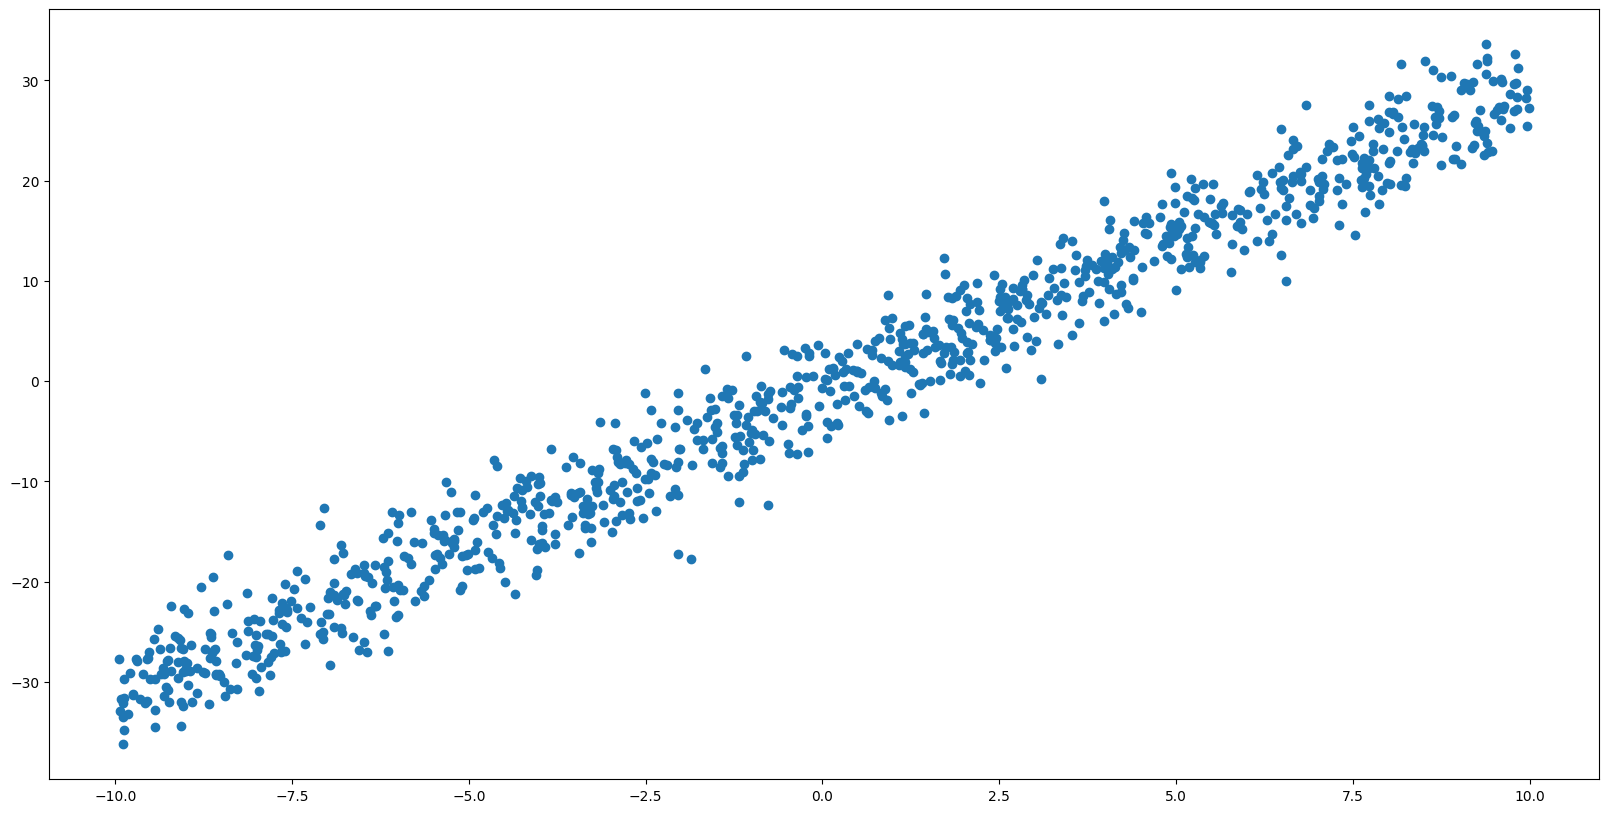

In [ ]:
plt.scatter(x=xs, y=ys)

In [ ]:
coefs = linear_model(xs, ys)
predictions = coefs[0] + xs*coefs[1]
errors = ys - predictions

In [ ]:
coefs

array([-1.03445336,  3.02624198])

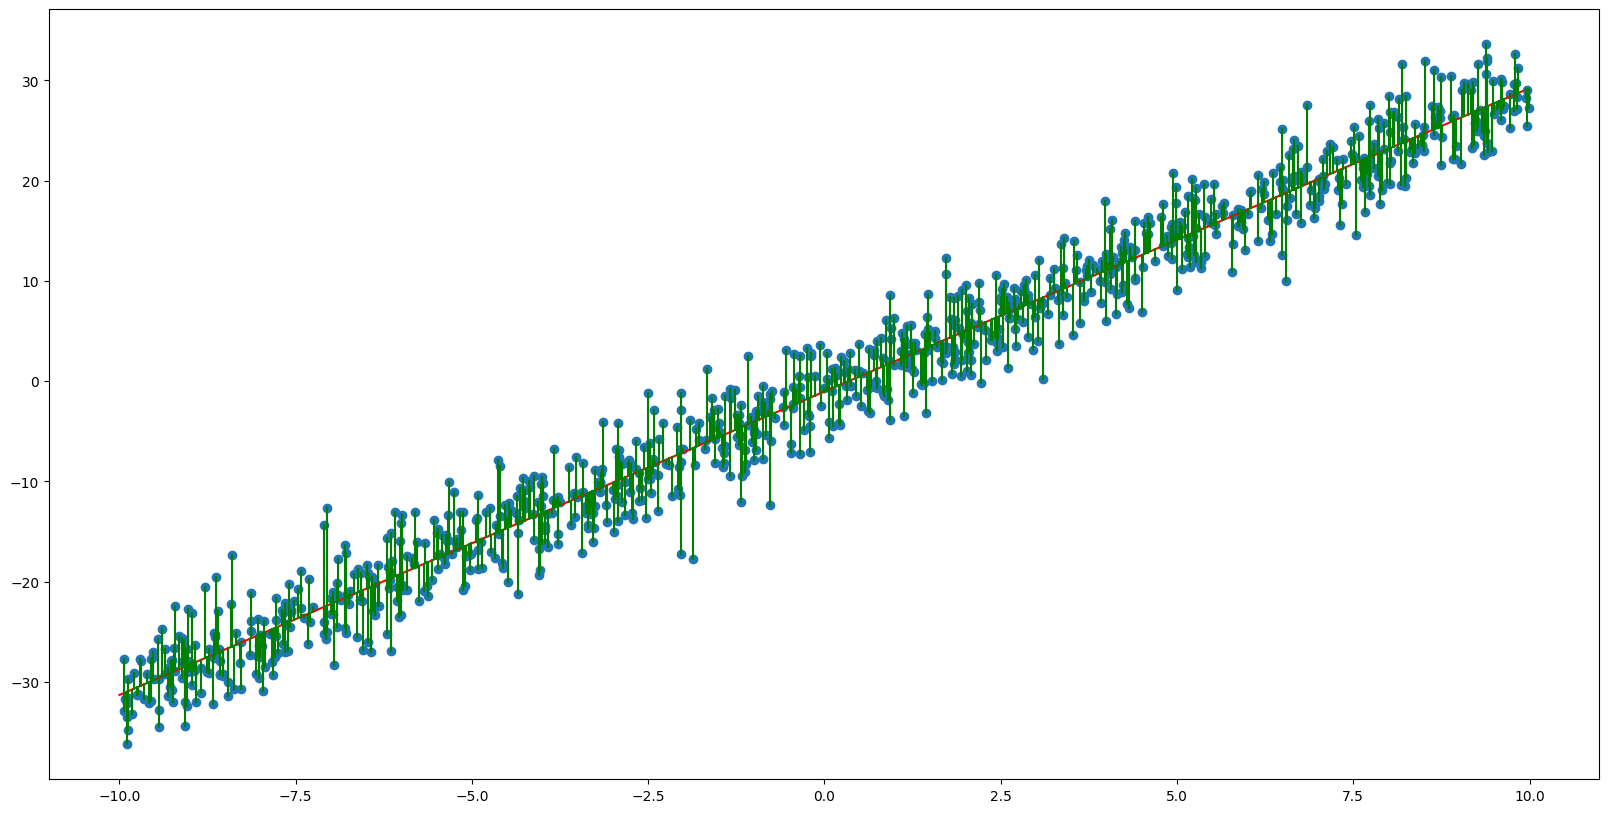

In [ ]:
range = numpy.arange(-10, 10, 0.1)
plt.scatter(x=xs, y=ys)
plt.plot(range, coefs[0] + range*coefs[1], color='red')
for x, y, p in zip(xs, ys, predictions):
  plt.plot([x,x], [y, p], color='green')
plt.show()

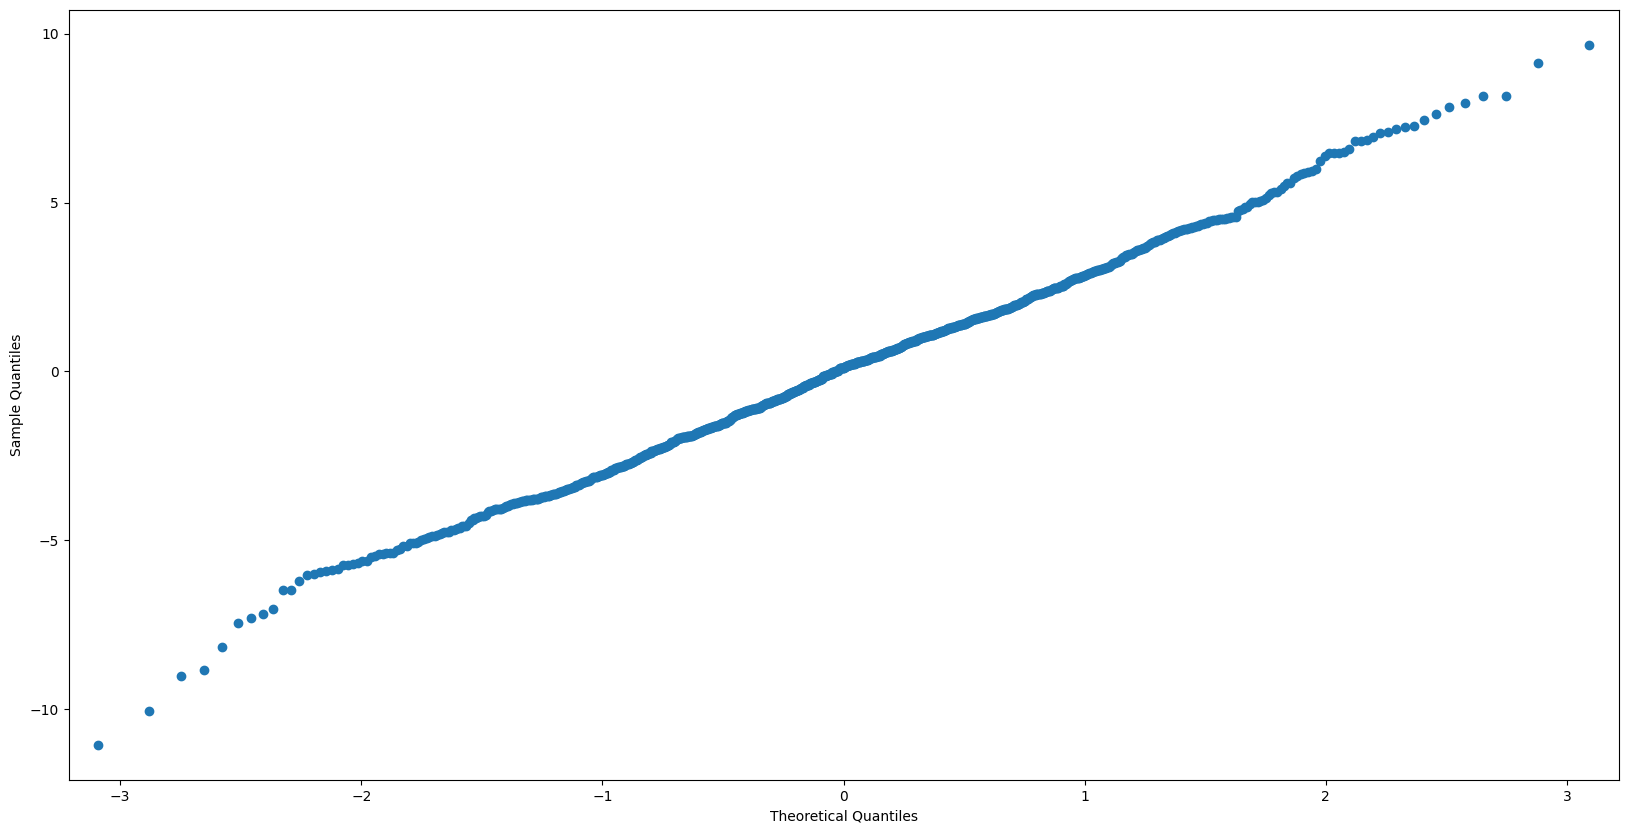

In [ ]:
sm.qqplot(errors)
plt.show()

# Some Non-Linear Data

In [ ]:
xs, ys = nonlinear_data_generator1(-0.8, 3, [-3,3], 1000, 8675309)

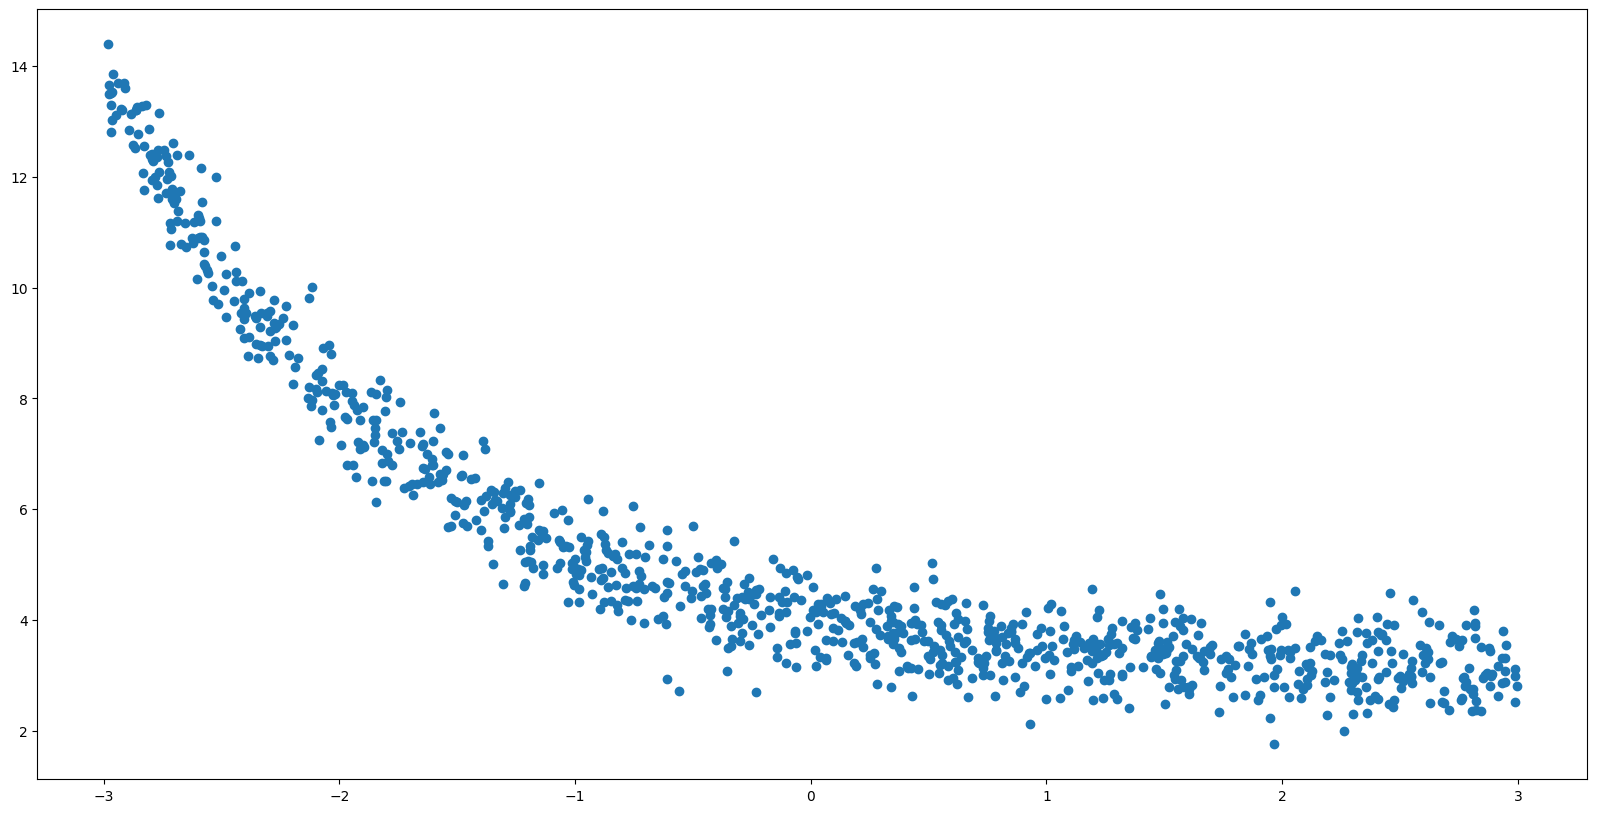

In [ ]:
plt.scatter(xs, ys)

In [ ]:
coefs = linear_model(xs, ys)

In [ ]:

coefs = linear_model(xs, ys)
predictions = coefs[0] + xs*coefs[1]
errors = ys - predictions

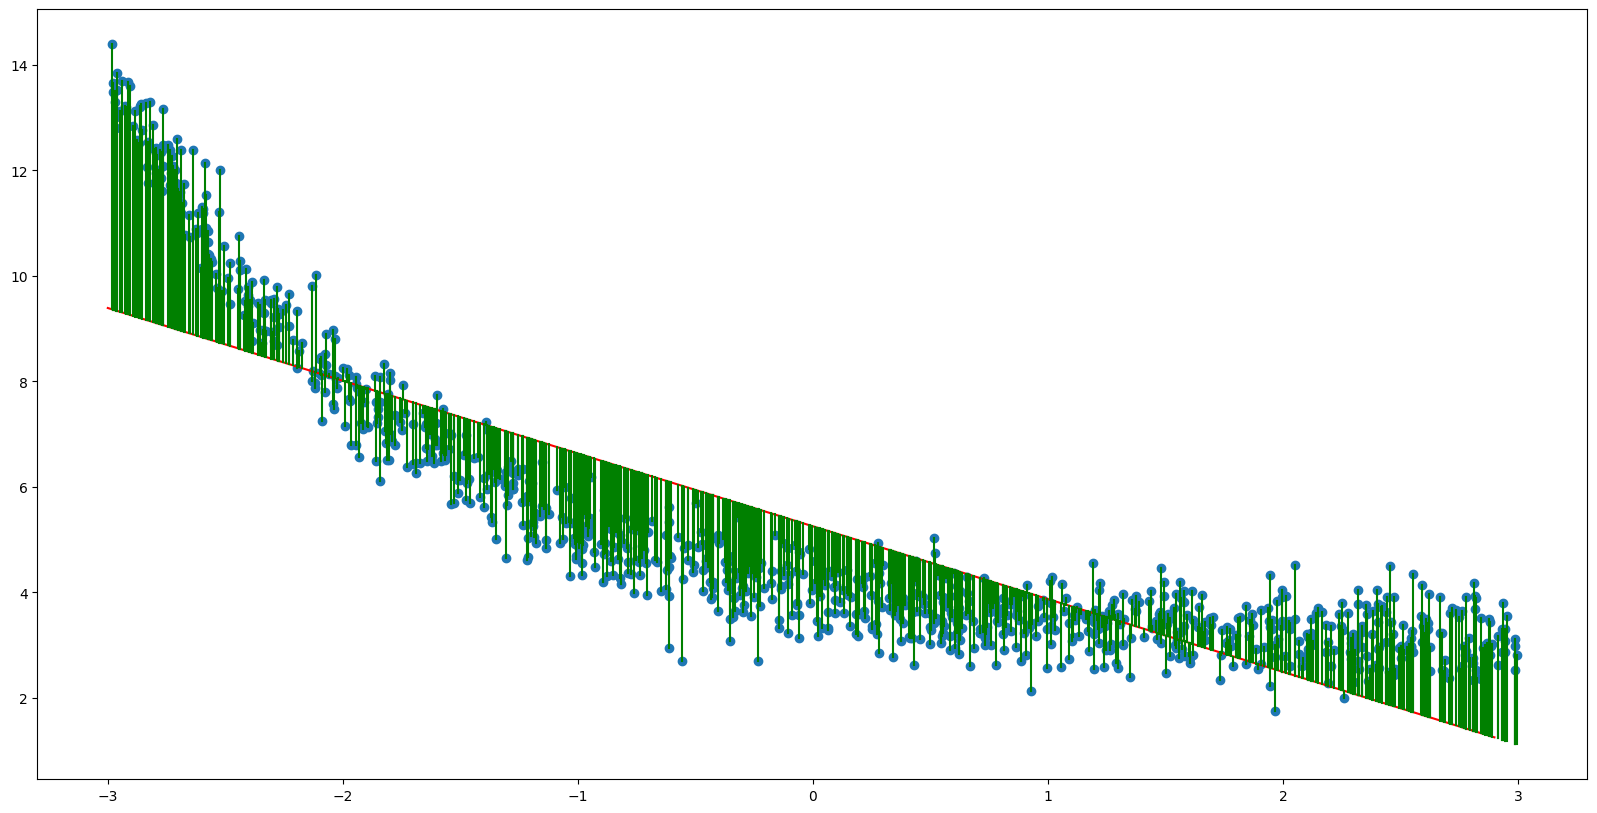

In [ ]:
range = numpy.arange(-3, 3, 0.1)
plt.scatter(x=xs, y=ys)
plt.plot(range, coefs[0] + range*coefs[1], color='red')
for x, y, p in zip(xs, ys, predictions):
  plt.plot([x,x], [y, p], color='green')
plt.show()

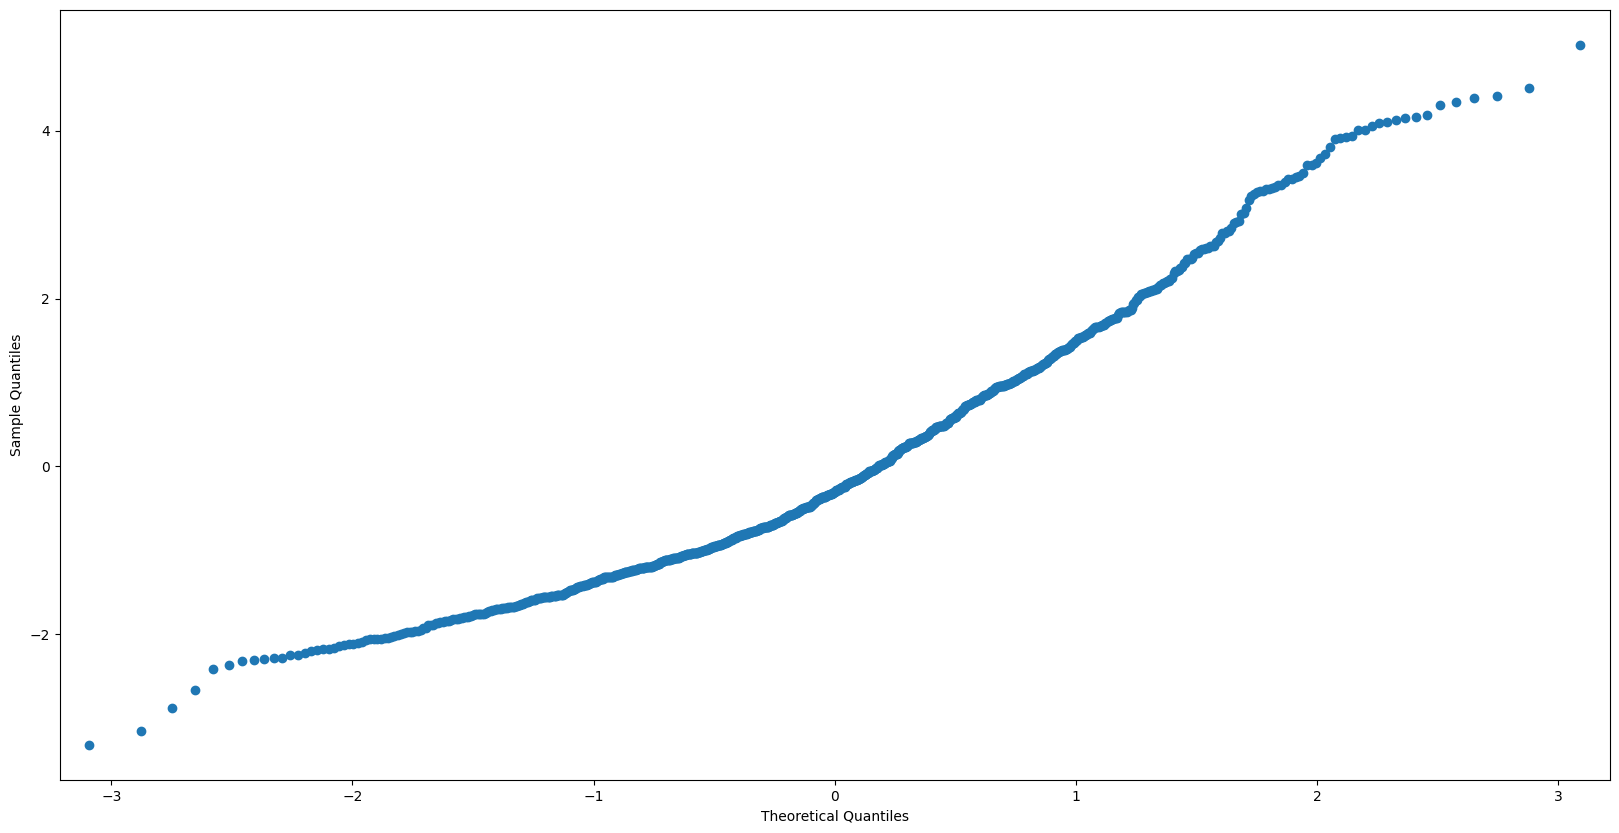

In [ ]:
sm.qqplot(errors)
plt.show()

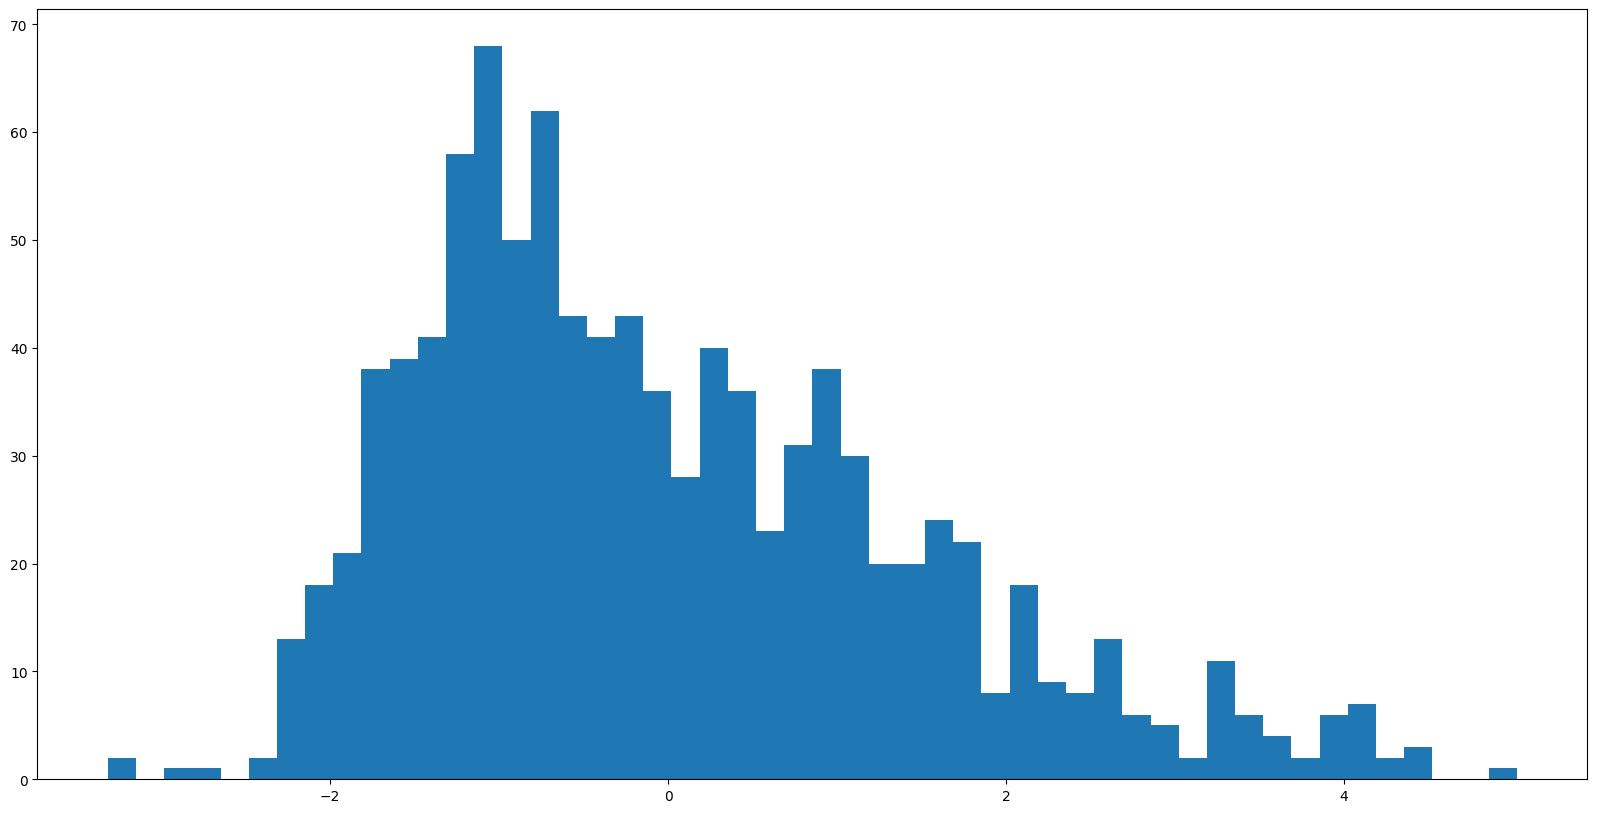

In [ ]:
plt.hist(errors, bins=50)
plt.show()

# Up In Dimension

In [ ]:
rng = numpy.random.default_rng(seed=8675309)
m = rng.integers(low=-5, high=10, size=500)
xs, ys = linear_data_generator2(m, 2.2, [-10, 10], 10000, seed=8675309)

In [ ]:
xs.shape

(10000, 500)

In [ ]:
coefs = linear_model(xs, ys)

[703.96288095 703.20821949 701.05037057 699.79985651 697.99998142
 696.8134404  695.89576621 694.1330728  693.81605637 692.45101681
 690.91735933 690.47844086 688.7229645  687.86437474 687.22192969
 685.93446168 685.48939407 684.48783502 684.1446243  683.21928045
 682.22991169 681.09230245 680.03861116 679.75307815 679.37032047
 679.34483493 677.17596105 676.68661259 676.40247656 675.96573659
 675.45873761 675.08814566 674.6754518  673.45481234 672.66826281
 672.07867306 671.57609228 670.8420246  670.50861478 669.14507531
 668.71601622 668.57937606 667.96672818 667.40339533 667.04430462
 666.30559128 665.7060296  665.39630378 665.22379992 664.23600723
 663.42035872 663.28201594 662.85823456 661.8533957  660.89337844
 659.92387761 659.62249819 659.11609282 658.10033513 657.37569659
 657.08993698 656.66082857 656.16651633 655.66269518 655.16965476
 654.49080552 653.95746596 653.40962773 653.30580865 652.39796912
 652.07344851 651.65379708 651.14862338 650.26100546 649.65223778
 649.61862

In [ ]:
coefs.shape

(501, 1)

In [ ]:
preds = coefs[0][0] + numpy.dot(xs, numpy.reshape(coefs[1:], (-1,1)))
errors = ys - preds

In [ ]:
errors = numpy.reshape(errors, (-1,))

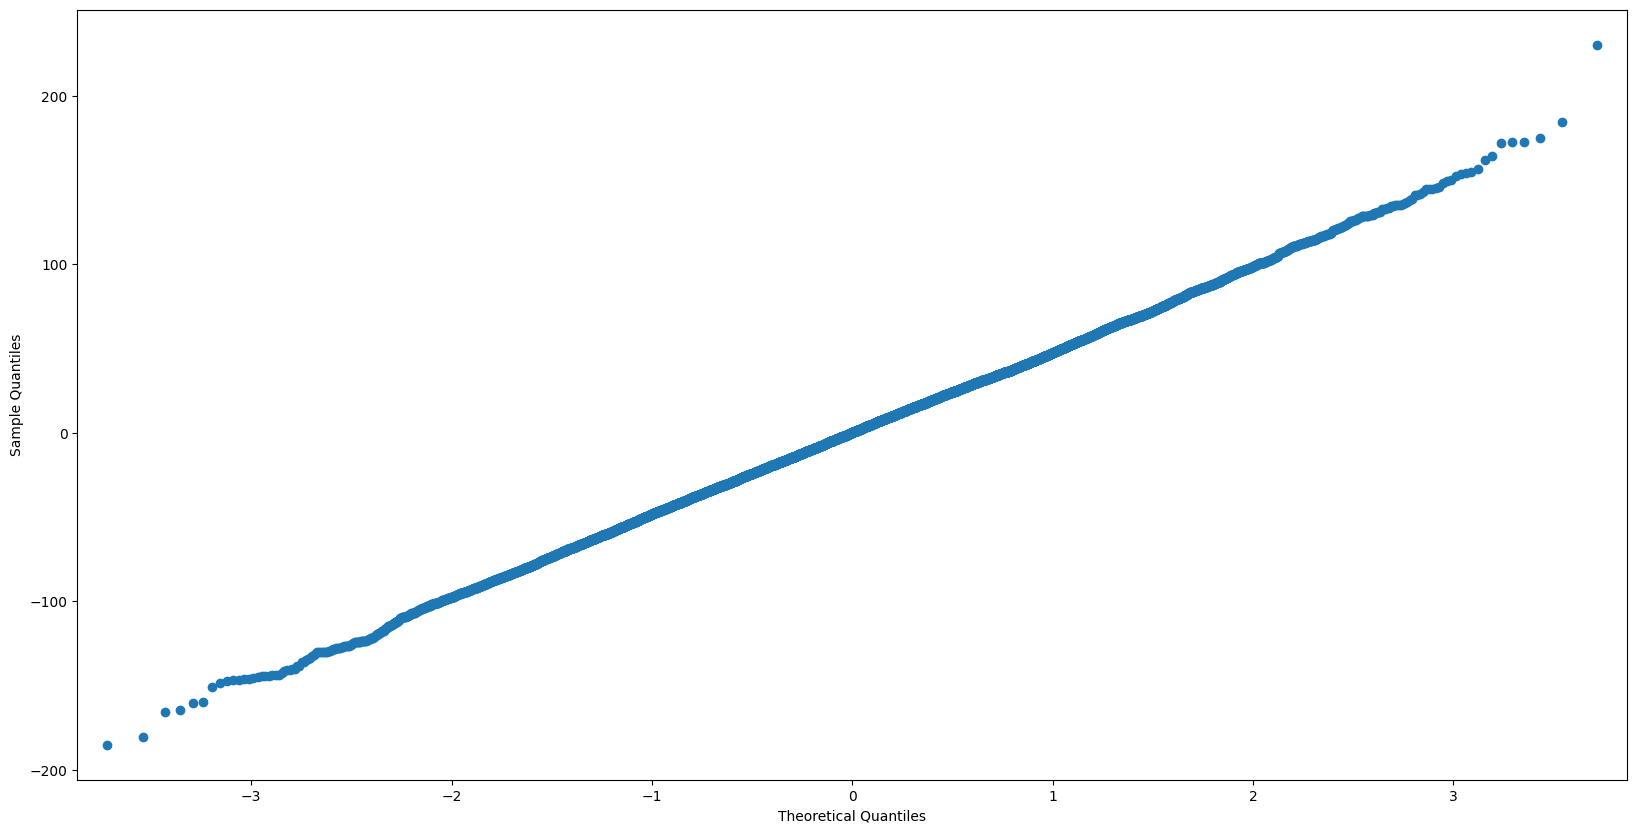

In [ ]:
sm.qqplot(errors)
plt.show()

# Back To Non-Linearity

In [ ]:
xs, ys = nonlinear_data_generator1(-0.3, 4.1, [-8, 8], 10, 867309)

In [ ]:
xs = numpy.reshape(xs, (-1,1))
higher_orders = numpy.hstack([numpy.power(xs, n) for n in numpy.arange(1, 10,1)])

In [ ]:
higher_orders.shape

(10, 9)

In [ ]:
coefs = linear_model(higher_orders, ys)

[1.12225357e+08 7.22256623e+06 7.42918795e+04 1.44580264e+04
 5.50459491e+02 7.08106726e+01 1.00158667e+01 2.26998646e+00
 6.05291719e-01 1.91292572e-02]


In [ ]:
coefs

array([ 3.86245106e+00, -1.30728248e+00,  2.07769081e-01,  2.20536180e-01,
       -4.97663843e-03, -1.30548777e-02, -2.23471096e-05,  2.63027812e-04,
        1.16423254e-06, -1.72278264e-06])

In [ ]:
preds = coefs[0] + numpy.dot(higher_orders, numpy.reshape(coefs[1:], (-1,1)))
errors = ys - numpy.reshape(preds, (-1,))

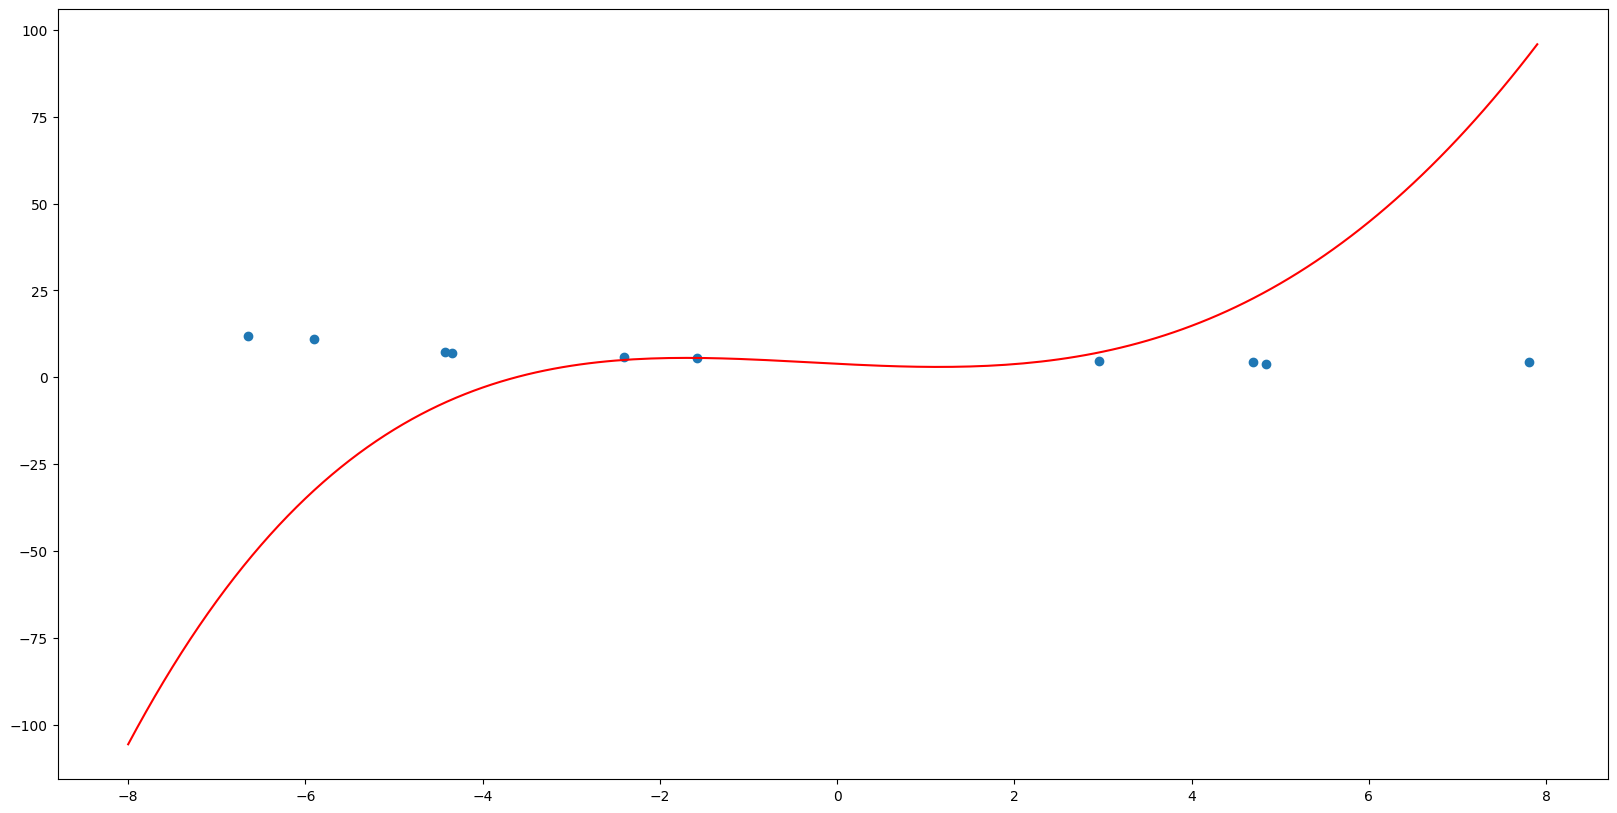

In [ ]:
range = numpy.arange(-8, 8, 0.1)
plt.scatter(x=xs, y=ys)
plt.plot(range, coefs[0] + range*coefs[1] + numpy.power(range, 2)*coefs[2] + numpy.power(range, 3)*coefs[3] + numpy.power(range, 4)*coefs[4], color='red')
plt.show()

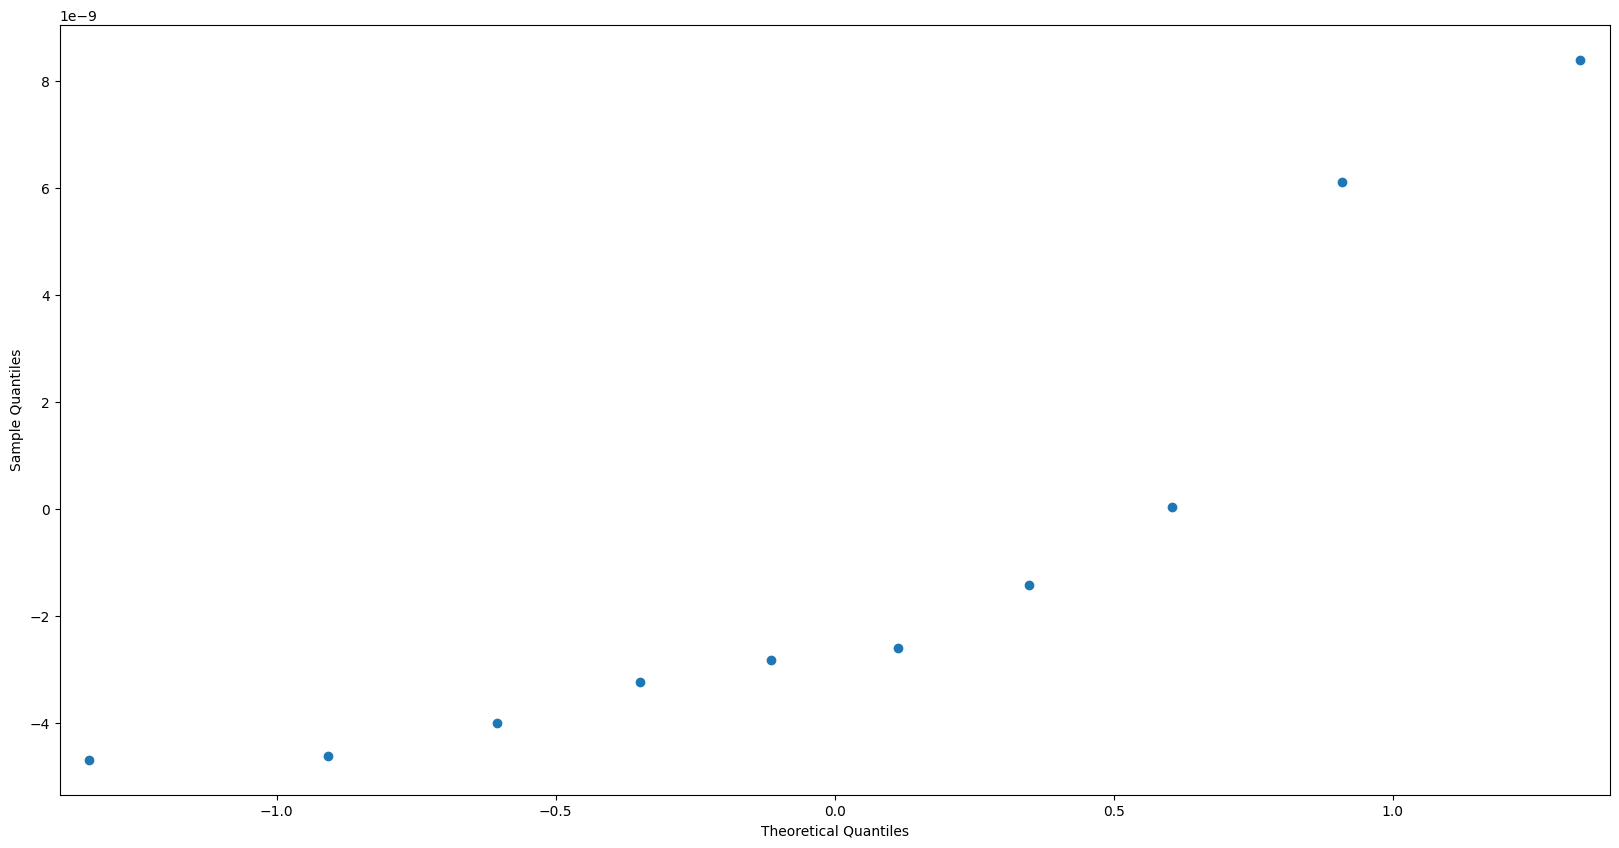

In [ ]:
sm.qqplot(errors)
plt.show()